# Домашнее задание 2: OCR + описание сцены + сравнение стратегий декодирования

В этом домашнем задании вы будете работать с комиксами по вселенной Harry Potter (в .zip файле).

Ваш пайплайн будет состоять из нескольких этапов:

1. **Запустить OCR** с помощью EasyOCR и извлечь текст с комикс-панели.
2. **Попробовать разные варианты предобработки изображения** и сравнить качество OCR с эталонным текстом.
3. **Найти лучший OCR-результат**.
4. **Сгенерировать короткое описание сцены** с помощью LLM
5. **Сравнить greedy search и beam search**.

Сдавать домашнее задание нужно через эту [форму](https://forms.gle/VTtSmnvMLdQHmWEp6). Правила сдачи никак не меняются.

Дедлайн: 26.04.2026 23:59



## Установка библиотек


In [ ]:
# Устанавливаем необходимые библиотеки
!pip install -q easyocr opencv-python pillow matplotlib pandas numpy transformers sentencepiece torch rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.8 MB/s eta 0:00:00


In [ ]:
# Импортируем стандартные библиотеки для обработки данных и визуализации.

import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

# Импортируем библиотеку для OCR.
import easyocr

# Импортируем инструменты для fuzzy matching.
# Они понадобятся, чтобы сравнивать OCR-результат с эталонным текстом.
from rapidfuzz import fuzz

# Импортируем инструменты Hugging Face для seq2seq-генерации
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


## Работа с датасетом - 0.5 балла

У вас есть 2 файла: в одном из них сгенерированные image caption, в другом - groundtruth для OCR. Объедините их в один датафрейм, с которым вам будет удобно работать


In [ ]:
# Пример датасета.

df = pd.DataFrame(DATA)

## Смотрим на изображения

Перед запуском OCR стоит сначала посмотреть на изображения вручную.



In [ ]:
def show_image(path, title=None, figsize=(8, 6)):
    """
    Показывает изображение с диска с помощью PIL и matplotlib.

    Параметры:
        path (str): путь к файлу изображения
        title (str или None): заголовок над изображением
        figsize (tuple): размер области вывода
    """
    img = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()



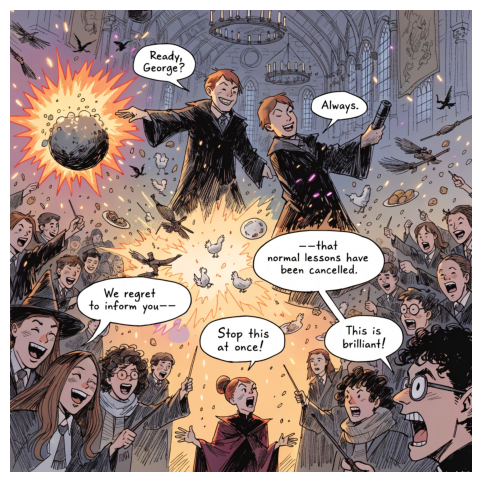

In [ ]:
show_image('/content/a-dramatic-comic-panel-in-the-harry-potter-univers (1).png') #Пример

## Задание 1 - 3 балла

1. Проведите эксперименты с параметрами paragraph, x_ths, y_ths,  detail для нескольких изображений. Напишите свои выводы - 1 балл
2. Исправьте функцию process_comic, чтобы она принимала на вход как путь к изображению, так и уже само изображение - 0.5 балла
2. Допишите код для сортировки speech bubbles по координате y. Помогает ли это? - 0.5 балла
3. Проанализируйте ошибки, которые встречаются при распознавании символов, выделите наиболее частые типы ошибок  - 1 балл
4. Вам необходимо извлечь текст для всех изображений из датасета (с учетом проведенных экспериментов) и сохранить полученнные результаты

In [ ]:
# ['en'] - язык
# Параметр gpu=False заставляет модель работать на CPU.
reader = easyocr.Reader(['en'], gpu=False)

def process_comic(image_path):
    image = cv2.imread(image_path)

    # OCR с включенным объединением в абзацы
    # paragraph=True — активирует алгоритм группировки
    # detail=1 возвращает координаты, текст и уверенность (confidence)
    # x_ths — порог объединения по горизонтали (по умолчанию 0.5)
    # y_ths — порог объединения по вертикали (по умолчанию 0.5)
    # Если реплики разных героев сливаются, эти значения нужно УМЕНЬШАТЬ.
    results = reader.readtext(
        image,
        paragraph=True,
        x_ths=0.7,
        y_ths=0.7,
        detail=1
    )

    print(f"После группировки найдено блоков: {len(results)}")

    structured_results = []

    for (bbox, text) in results:
        # При paragraph=True EasyOCR не возвращает confidence (prob) для всего блока
        (top_left, top_right, bottom_right, bottom_left) = bbox
        x, y = int(top_left[0]), int(top_left[1])

        structured_results.append({
            "coords": (x, y),
            "text": text
        })

        # Рисуем рамки объединенных блоков
        cv2.rectangle(image, tuple(map(int, top_left)), tuple(map(int, bottom_right)), (255, 0, 0), 3)
        # Выводим текст чуть выше рамки
        cv2.putText(image, "Block", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # ЗАДАНИЕ: сортировка по Y (у вас есть structured_results['coords'])
    # Даже если блоки склеены, они могут идти в списке в неправильном порядке
    # (например, сначала нижний бабл, потом верхний).
    #sorted_data = sorted()

    return structured_results, image

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


После группировки найдено блоков: 7


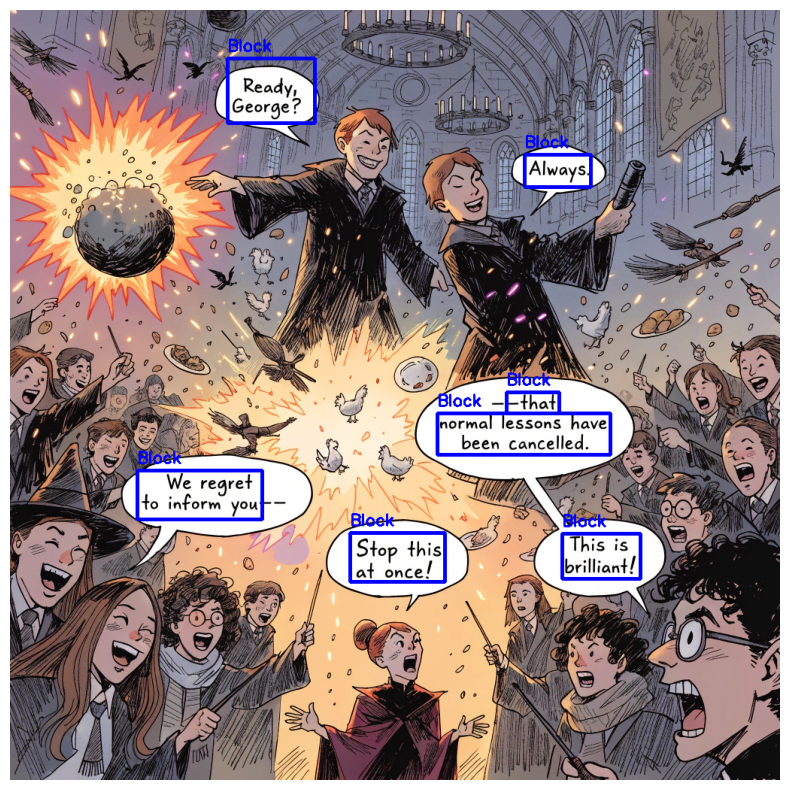

Сырой вывод OCR:
[(289, 64)]: Readye? George
[(660, 508)]: ~that
[(568, 536)]: normal lessons have been cancelled_
[(169, 612)]: We regret to inform you
[(452, 695)]: Stop this at oncel
[(734, 696)]: This is brilliantl
[(684, 192)]: Always_


In [ ]:
# Запуск
raw_data, debug_image = process_comic('/content/a-dramatic-comic-panel-in-the-harry-potter-univers (1).png') #Пример

# Посмотрим, что получилось
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(debug_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Вывод сырого текста для проверки
print("Сырой вывод OCR:")
for item in raw_data:
    print(f"[{item['coords']}]: {item['text']}")

# Задание 2 - 3 балла

1. Допишите код для реализации вспомогательных функции для предобработки изображения. Качество OCR очень часто зависит от предобработки. Реализуем следующие шаги:

- перевод в grayscale;
- увеличение изображения;
- подавление шума;
- thresholding / binarization.

1,5 балла

2. Допишите код для визуализации преобработанных изображений - 0,5
3. Возьмите 4 изображения, с которыми easyocr плохо справился, и протестируйте на них различные преобразования. Можно не брать все способы предобработки, но обоснуйте, почему вы выбрали именно эти. Проанализируйте, стал ли OCR работать лучше. - 1 балл




In [ ]:
def load_image_cv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл не найден: {path}")

    image = cv2.imread(path)

    if image is None:
        raise ValueError(f"Не удалось открыть изображение: {path}")

    return image

In [ ]:
def to_grayscale(image):
    """
    ЗАДАНИЕ: Переведите изображение в оттенки серого.
    Цвет (RGB) часто создает лишний 'шум' для алгоритмов детекции текста.
    ИСПОЛЬЗУЙТЕ cv2.COLOR_BGR2GRAY
    """
    return # ВАШ КОД ЗДЕСЬ


def apply_resize(image, scale=2.0):
    """
    ЗАДАНИЕ: Увеличьте изображение в scale раз.
    Увеличение помогает выделить детали букв.
    ИСПОЛЬЗУЙТЕ: cv2.resize с интерполяцией cv2.INTER_CUBIC (она лучше сохраняет края).
    """
    h, w = image.shape[:2]
    new_w = int(w * scale)
    new_h = int(h * scale)
    # ВАШ КОД ЗДЕСЬ (вызовите cv2.resize)
    return


def apply_median_blur(image, ksize=3):
    """
    ЗАДАНИЕ: Примените медианный фильтр.
    Медианный фильтр заменяет пиксель средним значением в окружении, эффективно удаляя этот мусор,
    но сохраняя границы букв более четкими, чем обычное размытие.
    ИСПОЛЬЗУЙТЕ: cv2.medianBlur(image, ksize)
    """
    return # ВАШ КОД ЗДЕСЬ


def apply_threshold(image, threshold_type="otsu", binary_inv=False):
    """
    ЗАДАНИЕ: Сделайте изображение строго черно-белым (бинаризация).
    OCR работает лучше всего, когда есть идеальный контраст: черный текст на белом фоне.

    ПАРАМЕТРЫ:
    - otsu: Автоматически выбирает порог яркости, анализируя гистограмму.
            Идеально, когда освещение на картинке равномерное.
    - adaptive: Вычисляет порог для каждой маленькой области отдельно.
                Помогает, если на комиксе есть тени или градиенты.
    """
    if len(image.shape) == 3:
        image = to_grayscale(image)

    if threshold_type == "otsu":
        # Указание: Используйте cv2.threshold с флагом cv2.THRESH_OTSU.
        # binary_inv поможет сделать текст черным, если фон изначально темный.
        flag = cv2.THRESH_BINARY_INV if binary_inv else cv2.THRESH_BINARY
        _, out = cv2.threshold(image, 0, 255, flag + cv2.THRESH_OTSU)
        return out

    if threshold_type == "adaptive":
        # Указание: Используйте cv2.adaptiveThreshold.
        # Попробуйте параметры blockSize=31 и C=11.
        # ВАШ КОД ЗДЕСЬ
        pass

    return image

def preprocess_image(
    path,
    resize_scale=1.0,
    grayscale=True,
    blur=False,
    blur_ksize=3,
    threshold_type=None,
    binary_inv=False
):
    """
    Главная функция-конвейер (Pipeline).
    Студенты должны последовательно применить функции выше.

    СОВЕТ: Сначала делайте Resize, потом Grayscale, а Threshold — в самом конце.
    """
    # 1. Загрузка (cv2.imread)
    # 2. Resize
    # 3. Grayscale
    # 4. Blur
    # 5. Threshold

    # ВАШ КОД ЗДЕСЬ
    pass

In [ ]:
def show_preprocessing_examples(path):
    """
    Показывает несколько вариантов предобработки для одного изображения.
    """
    # Пропишите варианты преобразований
    variants = {
        "original": load_image_cv(path),
        "gray": preprocess_image(# ВАШ КОД),
        "gray_x2": preprocess_image(# ВАШ КОД),
        "gray_x2_otsu": preprocess_image(# ВАШ КОД),
        "gray_x2_adaptive": preprocess_image(# ВАШ КОД),
        "gray_x2_blur_otsu": preprocess_image(# ВАШ КОД)),
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (name, img) in zip(axes, variants.items()):
        if len(img.shape) == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Реализуйте сравнительный анализ изображений с разной предобработкой ниже

In [ ]:
# Пример выбора предобработки:
sample_img = preprocess_image(
    sample_path,
    grayscale=True,
    resize_scale=2.0,
    threshold_type="otsu"
)
first_ocr_result = process_comic(sample_path)
sample_result = process_comic(sample_img)

# Визуализируем OCR-рамки.
boxed = draw_ocr_boxes(sample_img, sample_result)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("OCR-результат с bounding boxes")
plt.show()



## Задание 3 - 0.5 балла

1. Сравните OCR-результат с эталоном

Так как OCR часто ошибается не полностью, а частично (например, путает отдельные буквы или знаки препинания), удобно использовать **fuzzy matching**, а не только строгое точное совпадение.

2. Напишите выводы, что получилось, а с чем еще есть проблемы



In [ ]:
def normalize_text(text):
    """
    Нормализует текст перед сравнением.

    Здесь используется очень простая нормализация:
    - нижний регистр;
    - удаление лишних пробелов.

    При желании вы можете потом расширить эту функцию.
    """
    # ВАШ КОД ЗДЕСЬ

    return text


def compare_with_gold(pred_text, gold_text):
    """
    Сравнивает OCR-текст с эталонным текстом.

    Мы используем несколько fuzzy-метрик:
    - ratio
    - partial_ratio
    - token_sort_ratio

    Это удобно, потому что OCR может ошибаться частично,
    а не только полностью.
    """
    pred_norm = normalize_text(pred_text)
    gold_norm = normalize_text(gold_text)

    ratio = fuzz.ratio(pred_norm, gold_norm)
    partial = fuzz.partial_ratio(pred_norm, gold_norm)
    token_sort = fuzz.token_sort_ratio(pred_norm, gold_norm)

    return {
        "ratio": ratio,
        "partial_ratio": partial,
        "token_sort_ratio": token_sort
    }


## Задание 4

Задача - создать описание изображения на основе image caption и извлеченных c помощью OCR текстов. Необходимо сгенерировать краткое, но емкое описание самой ситуации, то есть задача - написать промпт так, чтобы по image caption LLM описала скорее событие и ситуацию в целом, чем все мелкие детали.

1. Напишите промпт для модели. Чем более подробный промпт, тем лучше будет результат. Можете попробовать дать пример, каким образом надо исправлять текст. Попробуйте хотя бы 3 разных формата промпта и подберите самый удачный (можно их протестировать на 3 изображениях)

2. Проведите эксперименты с greedy и beam search, сравните подходы и сохраните результаты для обоих. Напишите небольшой анализ по результатам экспериментов

3. Реализуйте простые автоматические метрики для сравнения описаний, полученных 2 разными способами, а также напишите функцию, которая будет выдывать наилучший результат

Чтобы получить 8, вы можете протестировать 1 промпт, запустить генерацию с beam и greedy search и написать небольшой анализ, что работает, а что - нет.

Чтобы получить 9, необходимо протестировать 3 промпта, запустить генерацию с beam и greedy search и написать небольшой анализ, что работает, а что - нет.

Чтобы получить 10, необходимо также реализовать автоматическую оценку.

Сохраните результаты генерации в ваш датасет, чтобы в конце распечатать несколько примеров из вашего датасета



In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Используем Qwen 2.5
model_id = "Qwen/Qwen2.5-1.5B-Instruct"


tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Устройство: cpu
Модель: google/flan-t5-base


In [ ]:
def build_input_text(caption, ocr_text):
    """
    Строит промпт для генерации описания сцены.
    Мы объединяем caption и OCR.
    """
 # ВАШ КОД ЗДЕСЬ
    return text


### Как модель генерирует текст: Greedy vs Beam Search

Когда LLM (как Qwen) исправляет текст, она не видит всё предложение целиком. Она предсказывает следующее слово, выбирая его из огромного словаря. Существует две основные стратегии этого выбора:

1. **Жадный поиск (Greedy Search)**
Это стратегия «живи моментом». На каждом шаге модель выбирает только одно самое вероятное слово.

**Как работает:** Модель видит, что у слова «Harry» вероятность 40%, а у «Hurry» — 30%. Она без раздумий берет «Harry».

Плюсы: Работает очень быстро.

Минусы: Модель может попасть в логическую ловушку. Ошибка, допущенная в начале предложения, потянет за собой цепочку других ошибок, и модель не сможет «вернуться» и исправить её.

В коде: num_beams=1, do_sample=False.

2. **Лучевой поиск (Beam Search)**
Это стратегия «планирования». Вместо одного варианта модель держит в памяти сразу несколько параллельных путей (лучей).

**Как работает:** Если мы задаем num_beams=5, модель строит 5 разных вариантов предложения одновременно.

В чем хитрость: В конце пути модель сравнивает не отдельные слова, а вероятность всей фразы целиком.


В коде: num_beams=5, early_stopping=True.

In [ ]:
def generate_qwen(text, method="greedy"):
    # Формируем промпт для Instruct-модели (можно попробовать отдельно улучшить OCR)
    prompt = f"Fix OCR errors in this text about Harry POtter: {text}\nFixed text:"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    if method == "greedy":
        output_ids = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            num_beams=1
        )
    else:
        output_ids = model.generate(
            **inputs,
            max_new_tokens=50, # Определите это значение потом сами
            do_sample=False,
            num_beams=5,
            early_stopping=True
        )

    # Отрезаем промпт, чтобы получить только ответ
    input_len = inputs.input_ids.shape[1]
    result = tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True)
    return result.strip()


raw_text = "Hxrry, it is is faster!"
print("Greedy:", generate_qwen(raw_text, method="greedy"))
print("Beam:",   generate_qwen(raw_text, method="beam"))

Greedy: "Harry, it's faster!" 

This correction fixes the following issues:
1. The original text had a typo where 'it' was misspelled as 'hxrry'.
2. The punctuation was incorrect; the correct punctuation for "it
Beam: Harry, it is faster!



Теперь мы запускаем обе стратегии декодирования для каждой сцены.


In [ ]:
greedy_outputs = []
beam_outputs = []

 # ВАШ КОД ЗДЕСЬ

##  Добавляем  автоматическое сравнение

Вам необходимо реализовать несколько (минимум 3) простых проверок для определения лучшего описания изображения. Можете сравнивать длину текста, число уникальных слов, сравнивать с тем, что вы изначально подавали в промпт (BLEU, ROUGE). Можете попробовать реализовать LLM-as-Judge с этой же моделью, заставить модель оценивать описания по каким-то критериям. Затем напишите функцию, которая автоматически по 3 или более параметрам будем выдавать лучший вариант описания. Здесь можно использовать любые библиотеки.

Напишите краткий анализ.

*   Почему вы выбрали такие метрики?
*   Оцените пару примеров самостоятельно. Совпадает ли ваша оценка с автоматической? Если нет, то предположите, по какой причине.

В этих комиксах есть картинки как по оригинальным произведениям, так и с фактическими ошибками, не используйте это как критерий для оценки.






In [ ]:
# ВАШ КОД ЗДЕСЬ

# Challenge


**Цель задания**

Построить простую модель классификации, которая по вашим трём параметрам (критериям для оценки) будет предсказывать, является ли описание изображения хорошим или плохим, и проанализировать:


*  насколько хорошо работают выбранные признаки;
*  какие из них самые важные;
*  можно ли по ним надёжно оценивать качество описаний.

1. Возьмите 20 примеров описаний из датасета и сделайте ручную разметку.

1 - хорошее описание

Примерные критерии:


*   соответствует изображению
*   содержит ключевые объекты
*   не слишком общее

0 - плохое описание

2. К этим же примерам создайте автоматическую разметку

Постройте автоматическую метку качества на основе трёх признаков.
Для каждого признака задайте свой порог. Например, если признаки оцениваются по шкале от 1 до 5, можно использовать такие правила:

feature_1 >= 4
feature_2 >= 4
feature_3 >= 3

3. Разделите данные на обучающую и тестовую выборки.
Обучите модель Random Forest Classifier (sklearn), используя только признаки:
feature_1, feature_2, feature_3
Постройте две модели: Модель A (y = label_human), Модель B (y = label_auto)

4. Сравните importance признаков в разных моделях
Отличается ли важность признаков?

clf.feature_importances_

5. Сделайте вывод о метриках, которые вы выбрали для оценки описаний









